# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

# **1. Import Library**

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# **2. Memuat Dataset**

In [138]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

In [139]:
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [141]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


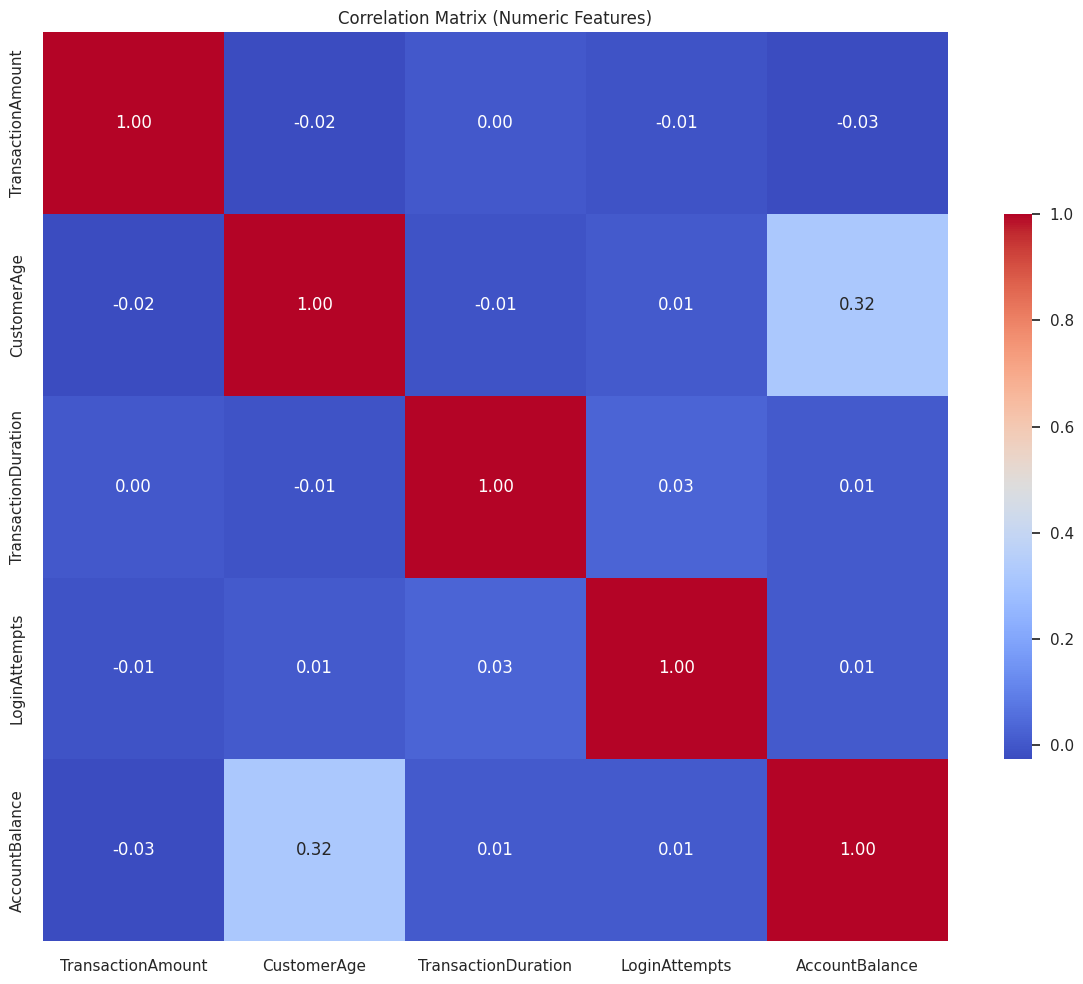

In [142]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink':0.6})
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()

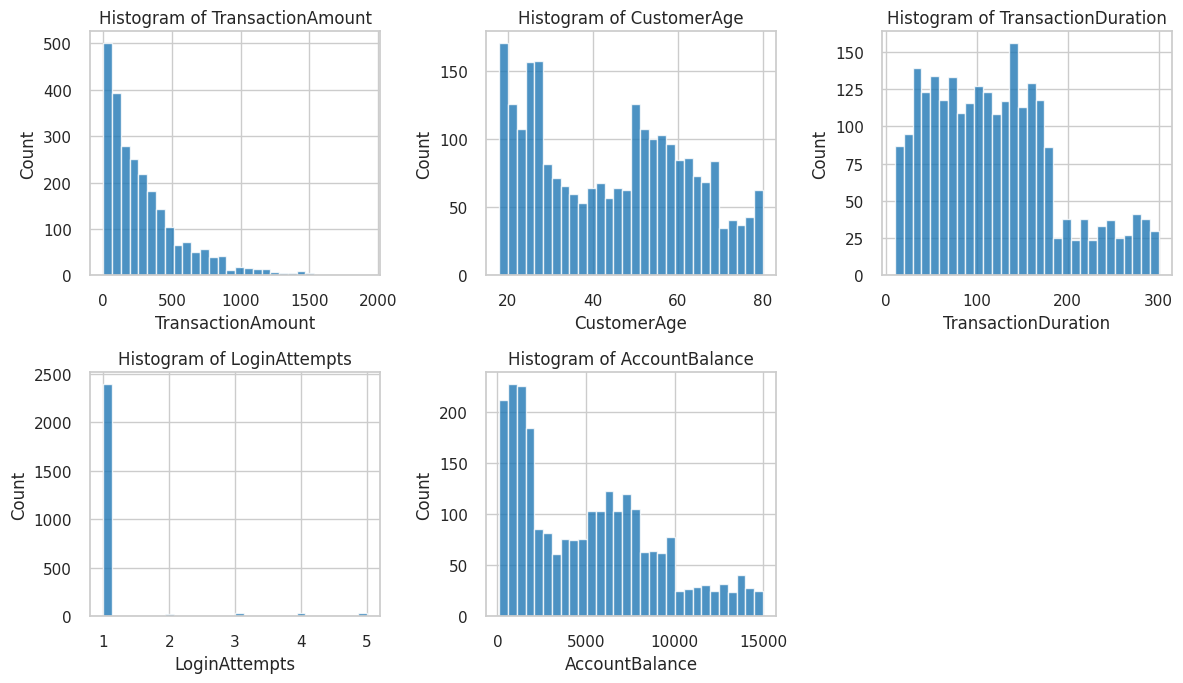

In [143]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
max_per_fig = 6
if len(num_cols) > 0:
    for start in range(0, len(num_cols), max_per_fig):
        subset = num_cols[start:start+max_per_fig]
        n = len(subset)
        cols = 3
        rows = int(np.ceil(n/cols))
        fig, axes = plt.subplots(rows, cols, figsize=(12, 3.5*rows))
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
        for i, col in enumerate(subset):
            ax = axes[i]
            data = df[col].dropna()
            ax.hist(data, bins=30, color='tab:blue', alpha=0.8)
            ax.set_title(f'Histogram of {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Count')
        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
        plt.close(fig)

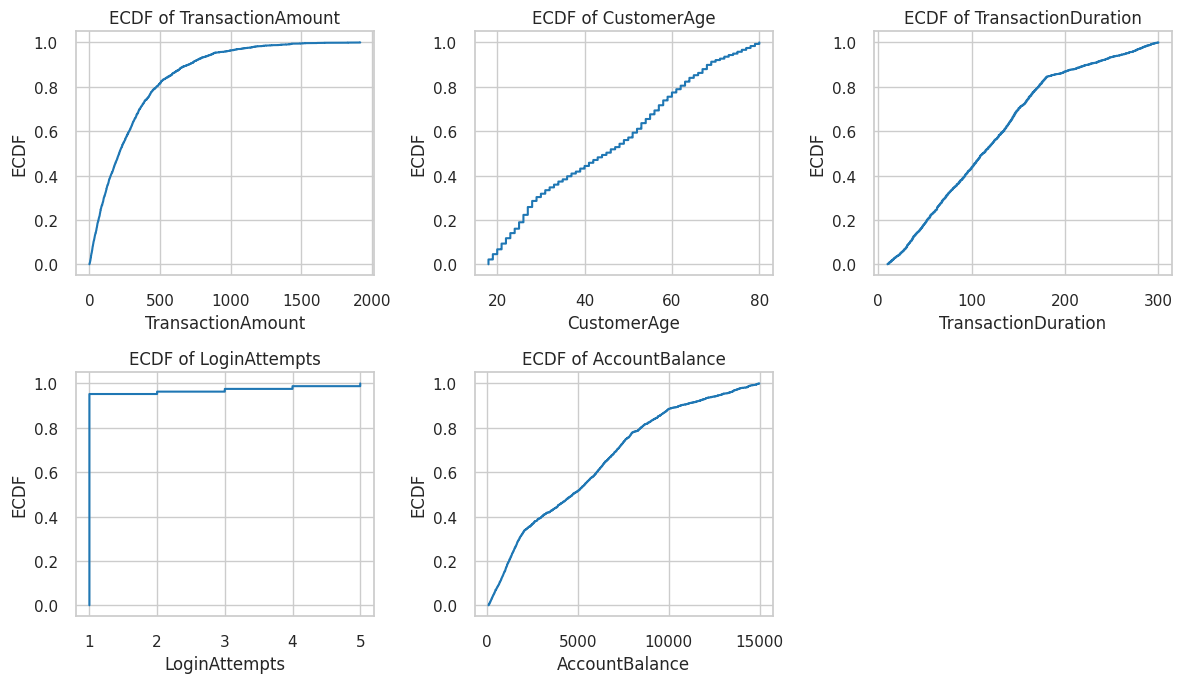

In [144]:
def plot_ecdf(series, ax, label=None):
    s = series.dropna().sort_values()
    n = len(s)
    if n == 0:
        return
    y = np.arange(1, n+1) / n
    ax.step(s, y, where='post', color='tab:blue')
    ax.set_xlabel(label if label else series.name)
    ax.set_ylabel('ECDF')
max_per_fig = 6
for start in range(0, len(num_cols), max_per_fig):
    subset = num_cols[start:start+max_per_fig]
    n = len(subset)
    cols = 3
    rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3.5*rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, col in enumerate(subset):
        plot_ecdf(df[col], axes[i], label=col)
        axes[i].set_title(f'ECDF of {col}')
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# **3. Pembersihan dan Pra Pemrosesan Data**

In [145]:
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [146]:
df.duplicated().sum()

np.int64(21)

In [147]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Target']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols].fillna(df[numeric_cols].median()))


from sklearn.feature_selection import SelectKBest, f_classif

if 'Target' in df.columns:
    X = df.drop('Target', axis=1)
    y = df['Target']

    k_best = 10
    k_to_select = min(k_best, X.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k_to_select)

    X_new = selector.fit_transform(X, y)

    selected_features = X.columns[selector.get_support()]

    print("Selected features after feature selection:")
    print(selected_features.tolist())

    df_selected = pd.DataFrame(X_new, columns=selected_features, index=X.index)
    df_selected['Target'] = y

    df = df_selected
    print("\nDataFrame with selected features:")
    display(df.head())
else:
    print("\nSkipping feature selection: 'Target' column not found (run after clustering).")


df.head()


Skipping feature selection: 'Target' column not found (run after clustering).


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,-0.972081,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.424796,Doctor,-0.550102,-0.203745,0.000725,2024-11-04 8:08:08
1,TX000002,AC00455,0.273272,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.312249,Doctor,0.310623,-0.203745,2.231209,2024-11-04 8:09:35
2,TX000003,AC00019,-0.586250,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.445136,Student,-0.908738,-0.203745,-1.028491,2024-11-04 8:07:04
3,TX000004,AC00070,-0.386079,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.051223,Student,-1.353446,-0.203745,0.892446,2024-11-04 8:09:06
4,TX000005,AC00411,-0.974281,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,0.017967,Student,1.128313,-0.203745,0.598462,2024-11-04 8:06:39


In [148]:
drop_candidates = ['TransactionID','AccountID','DeviceID','IP Address','IPAddress','MerchantID']
to_drop = [c for c in drop_candidates if c in df.columns]
df.drop(columns=to_drop, inplace=True)
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,-0.972081,2023-04-11 16:29:14,Debit,San Diego,ATM,1.424796,Doctor,-0.550102,-0.203745,0.000725,2024-11-04 8:08:08
1,0.273272,2023-06-27 16:44:19,Debit,Houston,ATM,1.312249,Doctor,0.310623,-0.203745,2.231209,2024-11-04 8:09:35
2,-0.586250,2023-07-10 18:16:08,Debit,Mesa,Online,-1.445136,Student,-0.908738,-0.203745,-1.028491,2024-11-04 8:07:04
3,-0.386079,2023-05-05 16:32:11,Debit,Raleigh,Online,-1.051223,Student,-1.353446,-0.203745,0.892446,2024-11-04 8:09:06
4,-0.974281,2023-10-16 17:51:24,Credit,Atlanta,Online,0.017967,Student,1.128313,-0.203745,0.598462,2024-11-04 8:06:39


In [149]:
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str).fillna('NA')
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,-0.972081,680,1,36,0,1.424796,0,-0.550102,-0.203745,0.000725,105
1,0.273272,1178,1,15,0,1.312249,0,0.310623,-0.203745,2.231209,192
2,-0.586250,1262,1,23,2,-1.445136,3,-0.908738,-0.203745,-1.028491,41
3,-0.386079,818,1,33,2,-1.051223,3,-1.353446,-0.203745,0.892446,163
4,-0.974281,1939,0,1,2,0.017967,3,1.128313,-0.203745,0.598462,16


In [150]:
df.columns.tolist()

['TransactionAmount',
 'PreviousTransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'TransactionDate']

In [151]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        try:
            df[c] = df[c].fillna(df[c].mode().iloc[0])
        except Exception:
            df[c] = df[c].fillna('NA')
df.isnull().sum()

,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
Channel,0
CustomerAge,0
CustomerOccupation,0
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [152]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print('Dropped duplicates:', before - after)
df.duplicated().sum()

Dropped duplicates: 23


np.int64(0)

In [153]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Target']
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = np.clip(df[col], lower, upper)
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2514.0,-0.045336,8.582606e-01,-1.019639,-0.734495,-0.293713,0.388007,2.071761
PreviousTransactionDate,2514.0,1256.328958,7.255820e+02,0.000000,628.250000,1256.500000,1884.750000,2485.000000
TransactionType,2514.0,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000
Location,2514.0,21.284010,1.239753e+01,0.000000,11.000000,21.000000,32.000000,43.000000
Channel,2514.0,1.010740,8.308396e-01,0.000000,0.000000,1.000000,2.000000,3.000000
CustomerAge,2514.0,-0.003209,9.983830e-01,-1.501409,-0.994950,0.017967,0.805791,1.987527
CustomerOccupation,2514.0,1.530231,1.150477e+00,0.000000,0.250000,2.000000,3.000000,4.000000
TransactionDuration,2514.0,0.001797,9.990892e-01,-1.568628,-0.808320,-0.105394,0.597532,2.591547
LoginAttempts,2514.0,-0.203745,1.171518e-14,-0.203745,-0.203745,-0.203745,-0.203745,-0.203745
AccountBalance,2514.0,0.000847,1.000390e+00,-1.291892,-0.926080,-0.096809,0.653260,2.545681


In [154]:
binned_cols = []
if 'TransactionAmount' in df.columns:
    df['TransactionAmount_bin'] = pd.qcut(df['TransactionAmount'], q=4, duplicates='drop')
    le = LabelEncoder()
    df['TransactionAmount_bin'] = le.fit_transform(df['TransactionAmount_bin'].astype(str))
    encoders['TransactionAmount_bin'] = le
    binned_cols.append('TransactionAmount_bin')
if 'CustomerAge' in df.columns:
    bins = [0,25,45,65,200]
    labels = ['young','adult','mid','senior']
    df['CustomerAge_bin'] = pd.cut(df['CustomerAge'], bins=bins, labels=labels).astype(str)
    le2 = LabelEncoder()
    df['CustomerAge_bin'] = le2.fit_transform(df['CustomerAge_bin'])
    encoders['CustomerAge_bin'] = le2
    binned_cols.append('CustomerAge_bin')
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionAmount_bin,CustomerAge_bin
0,-0.972081,680,1,36,0,1.424796,0,-0.550102,-0.203745,0.000725,105,2,1
1,0.273272,1178,1,15,0,1.312249,0,0.310623,-0.203745,2.231209,192,0,1
2,-0.586250,1262,1,23,2,-1.445136,3,-0.908738,-0.203745,-1.028491,41,1,0
3,-0.386079,818,1,33,2,-1.051223,3,-1.353446,-0.203745,0.892446,163,1,0
4,-0.974281,1939,1,1,2,0.017967,3,1.128313,-0.203745,0.598462,16,2,1


# **4. Membangun Model Clustering**

In [155]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2514.0,-0.045336,8.582606e-01,-1.019639,-0.734495,-0.293713,0.388007,2.071761
PreviousTransactionDate,2514.0,1256.328958,7.255820e+02,0.000000,628.250000,1256.500000,1884.750000,2485.000000
TransactionType,2514.0,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000
Location,2514.0,21.284010,1.239753e+01,0.000000,11.000000,21.000000,32.000000,43.000000
Channel,2514.0,1.010740,8.308396e-01,0.000000,0.000000,1.000000,2.000000,3.000000
CustomerAge,2514.0,-0.003209,9.983830e-01,-1.501409,-0.994950,0.017967,0.805791,1.987527
CustomerOccupation,2514.0,1.530231,1.150477e+00,0.000000,0.250000,2.000000,3.000000,4.000000
TransactionDuration,2514.0,0.001797,9.990892e-01,-1.568628,-0.808320,-0.105394,0.597532,2.591547
LoginAttempts,2514.0,-0.203745,1.171518e-14,-0.203745,-0.203745,-0.203745,-0.203745,-0.203745
AccountBalance,2514.0,0.000847,1.000390e+00,-1.291892,-0.926080,-0.096809,0.653260,2.545681


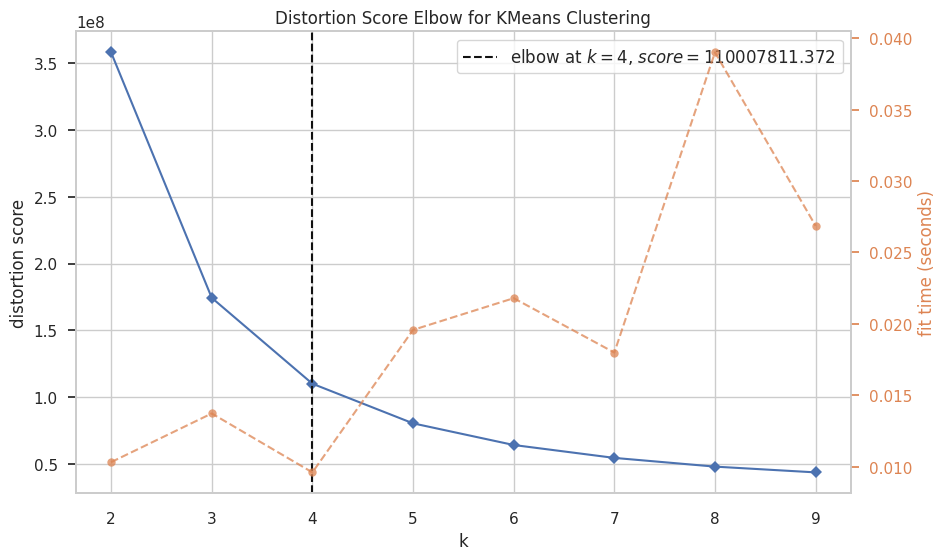

np.int64(4)

In [156]:
features = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[features]
model_k = KMeans(random_state=42)
visualizer = KElbowVisualizer(model_k, k=(2,10))
visualizer.fit(X)
visualizer.show()
elbow_k = visualizer.elbow_value_
elbow_k

In [157]:
n_clusters = int(elbow_k) if (('elbow_k' in globals()) and (elbow_k is not None)) else 4
model_kmeans = KMeans(n_clusters=n_clusters, random_state=42)
model_kmeans.fit(X)
labels = model_kmeans.labels_
df['Target'] = labels
df['Target'].head()

,Target
0,2
1,2
2,3
3,2
4,1


In [158]:
joblib.dump(model_kmeans, 'model_clustering.h5')

['model_clustering.h5']

In [159]:
sil_score = silhouette_score(X, df['Target'])
sil_score

np.float64(0.4987726138684096)

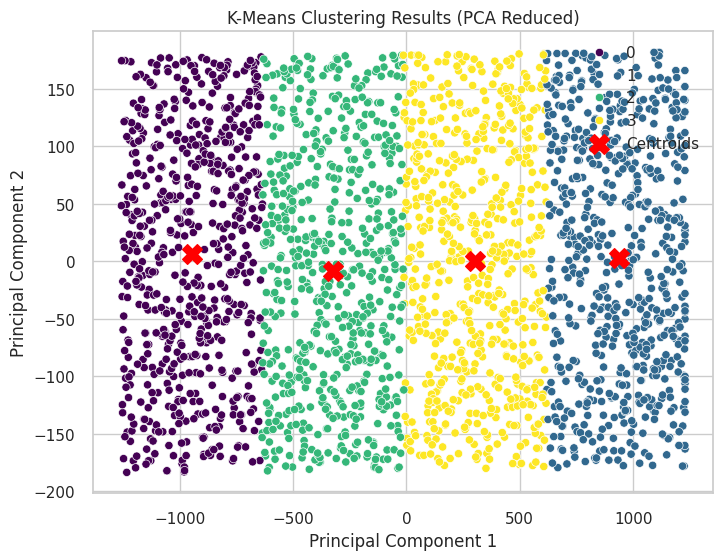

In [160]:
if 'PCA_df' not in globals():
    pca_model = PCA(n_components=2, random_state=42)
    pca_components = pca_model.fit_transform(X)
    PCA_df = pd.DataFrame(pca_components, columns=['PCA1','PCA2'])
    PCA_df['Target'] = df['Target'].reset_index(drop=True)

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Target', data=PCA_df, palette='viridis', legend='full')

if 'model_kmeans' in globals() and 'pca_model' in globals():
    centroids_pca = pca_model.transform(model_kmeans.cluster_centers_)
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroids')

plt.title('K-Means Clustering Results (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.show()

In [161]:
pca_model = PCA(n_components=2, random_state=42)
pca_components = pca_model.fit_transform(X)
PCA_df = pd.DataFrame(pca_components, columns=['PCA1','PCA2'])

k_pca = KMeans(n_clusters=n_clusters, random_state=42)
k_pca.fit(PCA_df)
PCA_df['Target'] = k_pca.labels_
PCA_df.head()

,PCA1,PCA2,Target
0,-576.157667,-77.218858,2
1,-78.354083,10.960268,2
2,5.981277,-139.881876,3
3,-438.286904,-18.903513,2
4,683.032701,-163.300661,1


In [162]:
joblib.dump({'pca_model': pca_model, 'kmeans_model': k_pca}, 'PCA_model_clustering.h5')

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

In [163]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Target']
agg_numeric = df.groupby('Target')[numeric_cols].agg(['mean','min','max'])

categorical_cols = [c for c in df.columns if c not in numeric_cols + ['Target']]
if len(categorical_cols) > 0:
    agg_categorical = df.groupby('Target')[categorical_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
else:
    agg_categorical = pd.DataFrame()

combined_agg_df = pd.concat([agg_numeric, agg_categorical], axis=1)

pd.set_option('display.max_columns', None)
display(combined_agg_df)

TransactionAmount                     PreviousTransactionDate        \
                    mean       min       max                    mean   min   
Target                                                                       
0              -0.051620 -1.017576  2.071761              310.003221     0   
1              -0.059977 -1.019639  2.071761             2194.324961  1877   
2              -0.086157 -1.015684  2.071761              933.000000   620   
3               0.016059 -1.019432  2.071761             1560.996830  1244   

             TransactionType           Location           Channel          \
         max            mean min max       mean min max      mean min max   
Target                                                                      
0        622             1.0   1   1  21.515298   0  43  0.971014   0   3   
1       2485             1.0   1   1  21.199372   0  43  1.061224   0   3   
2       1246             1.0   1   1  21.320000   0  43  1.011200   0   3   
3       1876             1.0   1   1  21.106181   0  43  0.998415   0   3   

       CustomerAge                     CustomerOccupation          \
              mean       min       max               mean min max   
Target                                                              
0        -0.062864 -1.501409  1.987527           1.492754   0   4   
1         0.004362 -1.501409  1.987527           1.519623   0   4   
2         0.015265 -1.501409  1.987527           1.526400   0   4   
3         0.029560 -1.501409  1.987527           1.581616   0   4   

       TransactionDuration                     LoginAttempts            \
                      mean       min       max          mean       min   
Target                                                                   
0                -0.035700 -1.568628  2.577201     -0.203745 -0.203745   
1                 0.026440 -1.568628  2.591547     -0.203745 -0.203745   
2                -0.008029 -1.568628  2.562856     -0.203745 -0.203745   
3                 0.023556 -1.568628  2.577201     -0.203745 -0.203745   

                 AccountBalance                     TransactionDate           \
             max           mean       min       max            mean min  max   
Target                                                                         
0      -0.203745      -0.007095 -1.291647  2.536598      188.888889   0  360   
1      -0.203745       0.030989 -1.285546  2.545681      181.673469   0  360   
2      -0.203745      -0.004932 -1.290445  2.526827      172.892800   0  360   
3      -0.203745      -0.016040 -1.291892  2.534720      180.144216   0  360   

       TransactionAmount_bin         CustomerAge_bin          
                        mean min max            mean min max  
Target                                                        
0                   1.495974   0   3        0.475040   0   1  
1                   1.500785   0   3        0.518053   0   1  
2                   1.462400   0   3        0.508800   0   1  
3                   1.565769   0   3        0.532488   0   1

## Karakteristik tiap cluster berdasarkan rentangnya.

1. **Cluster 0: Nasabah Pasif Stabil (Sebelum Inverse)**
- **Karakteristik Utama:** Rata-rata nilai pada fitur numerik cenderung normal atau sedikit di bawah rata-rata, dengan nilai *PreviousTransactionDate* yang rendah.
- **Analisis:** Mengindikasikan kelompok nasabah dengan **aktivitas transaksi stabil dan nilai transaksi rata-rata**, serta saldo akun yang konsisten.

2. **Cluster 1: Nasabah Produktif Saldo Tinggi (Sebelum Inverse)**
- **Karakteristik Utama:** Nilai *PreviousTransactionDate* sangat tinggi, fitur numerik lainnya cenderung normal atau sedikit di atas rata-rata.
- **Analisis:** Menonjolkan nasabah dengan **transaksi terbaru atau aktivitas transaksi tinggi**, serta saldo yang sedikit lebih tinggi.

3. **Cluster 2: Nasabah Pasif Rutin (Sebelum Inverse)**
- **Karakteristik Utama:** Nilai *PreviousTransactionDate* lebih rendah dibandingkan Cluster 1, fitur numerik lainnya cenderung normal.
- **Analisis:** Menunjukkan nasabah dengan **transaksi yang lebih lama** namun tetap memiliki pola stabil dan saldo normal.

4. **Cluster 3: Nasabah Aktif Nominal Tinggi Saldo Berfluktuasi (Sebelum Inverse)**
- **Karakteristik Utama:** Nilai rata-rata *TransactionAmount* sedikit di atas rata-rata, *PreviousTransactionDate* relatif baru, saldo sedikit lebih rendah.
- **Analisis:** Mencerminkan nasabah **aktif dengan intensitas transaksi tinggi namun dengan saldo yang cenderung berfluktuasi**.

# **6. Mengeksport Data**

In [164]:
'Target' in df.columns

True

In [165]:
df.to_csv('data_clustering.csv', index=False)

In [166]:
numeric_cols_scaled = [col for col in df.columns if col in scaler.feature_names_in_]

df_inverse = df.copy()

if 'scaler' in globals():
    df_inverse[numeric_cols_scaled] = scaler.inverse_transform(df_inverse[numeric_cols_scaled])

df_inverse.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionAmount_bin,CustomerAge_bin,Target
0,14.09,680,1,36,0,70.0,0,81.0,1.0,5112.21,105,2,1,2
1,376.24,1178,1,15,0,68.0,0,141.0,1.0,13758.91,192,0,1,2
2,126.29,1262,1,23,2,19.0,3,56.0,1.0,1122.35,41,1,0,3
3,184.50,818,1,33,2,26.0,3,25.0,1.0,8569.06,163,1,0,2
4,13.45,1939,1,1,2,45.0,3,198.0,1.0,7429.40,16,2,1,1


In [167]:
categorical_cols_encoded = [col for col in df_inverse.columns if col in encoders and col != 'Target']
for col in categorical_cols_encoded:
    le = encoders[col]
    df_inverse[col] = le.inverse_transform(df_inverse[col].astype(int))

df_inverse.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionAmount_bin,CustomerAge_bin,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,"(-1.021, -0.734]",young,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,"(-0.294, 0.388]",young,2
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,"(-0.734, -0.294]",nan,3
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,"(-0.734, -0.294]",nan,2
4,13.45,2023-10-16 17:51:24,Debit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 8:06:39,"(-1.021, -0.734]",young,1


In [168]:
numeric_cols_inv = df_inverse.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_inv = [c for c in numeric_cols_inv if c != 'Target']
agg_numeric_inv = df_inverse.groupby('Target')[numeric_cols_inv].agg(['mean','min','max'])

categorical_cols_inv = df_inverse.select_dtypes(include=['object','category']).columns.tolist()
if len(categorical_cols_inv) > 0:
    agg_categorical_inv = df_inverse.groupby('Target')[categorical_cols_inv].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
else:
    agg_categorical_inv = pd.DataFrame()

combined_agg_inv_df = pd.concat([agg_numeric_inv, agg_categorical_inv], axis=1)
pd.set_option('display.max_columns', None)
display(combined_agg_inv_df)

,"(TransactionAmount, mean)","(TransactionAmount, min)","(TransactionAmount, max)","(CustomerAge, mean)","(CustomerAge, min)","(CustomerAge, max)","(TransactionDuration, mean)","(TransactionDuration, min)","(TransactionDuration, max)","(LoginAttempts, mean)","(LoginAttempts, min)","(LoginAttempts, max)","(AccountBalance, mean)","(AccountBalance, min)","(AccountBalance, max)",PreviousTransactionDate,TransactionType,Location,Channel,CustomerOccupation,TransactionDate,TransactionAmount_bin,CustomerAge_bin
Target,,,,,,,,,,,,,,,,,,,,,,,
0,281.761019,0.86,899.2425,43.563607,18.0,80.0,116.858293,10.0,299.0,1.0,1.0,1.0,5081.896940,102.20,14942.78,2023-01-02 16:00:06,Debit,Boston,Branch,Doctor,2024-11-04 8:10:23,"(-0.294, 0.388]",nan
1,279.330757,0.26,899.2425,44.758242,18.0,80.0,121.189953,10.0,300.0,1.0,1.0,1.0,5229.534223,125.85,14977.99,nan,Debit,Fort Worth,Branch,Engineer,nan,"(-1.021, -0.734]",young
2,271.717592,1.41,899.2425,44.952000,18.0,80.0,118.787200,10.0,298.0,1.0,1.0,1.0,5090.279824,106.86,14904.90,2023-04-03 16:07:53,Debit,Indianapolis,Branch,Doctor,2024-11-04 8:07:18,"(-0.734, -0.294]",young
3,301.442143,0.32,899.2425,45.206022,18.0,80.0,120.988906,10.0,299.0,1.0,1.0,1.0,5047.219778,101.25,14935.50,2023-07-10 16:01:03,Debit,San Antonio,ATM,Student,nan,"(0.388, 2.072]",young


## Karakteristik tiap cluster berdasarkan rentangnya setelah inverse.

1. **Cluster 0: Nasabah Pasif Stabil**
- **Karakteristik Utama:** Usia rata-rata sekitar 43.56 tahun, saldo normal (sekitar $5081.90), transaksi rata-rata normal (sekitar $281.76) dengan durasi sedang. Mayoritas melakukan Debit di Branch, lokasi Boston, profesi Doctor.
- **Insight:** Cluster ini berisi nasabah yang cenderung tidak sering bertransaksi, namun memiliki saldo stabil. Mereka bisa menjadi target untuk program aktivasi atau produk investasi jangka panjang.

2. **Cluster 1: Nasabah Produktif Saldo Tinggi**
- **Karakteristik Utama:** Usia rata-rata sekitar 44.76 tahun, saldo sedikit lebih tinggi (sekitar $5229.53), transaksi rata-rata normal (sekitar $279.33) dengan durasi sedikit di atas rata-rata. Mayoritas melakukan Debit di Branch, lokasi Fort Worth, profesi Engineer.
- **Insight:** Nasabah di cluster ini aktif dan memiliki saldo yang baik. Mereka adalah nasabah loyal yang potensial untuk penawaran produk premium atau layanan prioritas.

3. **Cluster 2: Nasabah Pasif Rutin**
- **Karakteristik Utama:** Usia rata-rata sekitar 44.95 tahun, saldo stabil (sekitar $5090.28), transaksi rata-rata normal (sekitar $271.72) dengan durasi normal. Mayoritas melakukan Debit di Branch, lokasi Indianapolis, profesi Doctor.
- **Insight:** Mirip dengan Cluster 0, nasabah ini pasif namun rutin. Mereka bisa ditargetkan dengan penawaran yang meningkatkan frekuensi transaksi atau loyalitas.

4. **Cluster 3: Nasabah Aktif Nominal Tinggi Saldo Berfluktuasi**
- **Karakteristik Utama:** Usia rata-rata sekitar 45.21 tahun, saldo sedikit lebih rendah (sekitar $5047.22), transaksi rata-rata sedikit di atas rata-rata (sekitar $301.44) dengan durasi normal. Mayoritas melakukan Debit di ATM, lokasi San Antonio, profesi Student.
- **Insight:** Cluster ini aktif dengan nilai transaksi lebih tinggi, tetapi saldo cenderung berfluktuasi. Ini bisa mengindikasikan risiko anomali atau peluang untuk penawaran produk yang membantu pengelolaan finansial atau kredit.


In [169]:
df_inverse.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionAmount_bin,CustomerAge_bin,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,"(-1.021, -0.734]",young,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,"(-0.294, 0.388]",young,2
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,"(-0.734, -0.294]",nan,3
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,"(-0.734, -0.294]",nan,2
4,13.45,2023-10-16 17:51:24,Debit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 8:06:39,"(-1.021, -0.734]",young,1


In [170]:
df_inverse.to_csv('data_clustering_inverse.csv', index=False)

End of Code.